Question 1:
- Do Mock Exam scores, including cases where students didn't participate or score 0, significantly predict National Exam results?
Hypothesis 1:
- Mock Exam scores, even when some students score zero, have a significant positive impact on National Exam results.

Question 2:
- Among students who took the Mock Exam, do thier scores significantly predict National Exam results?
Hypothesis 2:
- For students who participated in the Mock Exam, higher scores have a significant positive impact on National Exam results.


Data Description
Period: Exam Cycle (1st - 6th) - 
Mock_Exam Average: Average score of number of mock exams students have taken
Exit_Exam Result: Final score in the national exit exam
Pass/Fail: Derived variable (Pass if National_Result >= 50, Fail otherwise)

In [21]:
import pandas as pd

url = "https://raw.githubusercontent.com/shineApril/Kujenga_Project_Nesredien/refs/heads/main/Mock%20Exam%20Vs%20Exit%20Exam.csv"
df = pd.read_csv(url)

#Create Pass/Fail column
df['Pass_Fail'] = df['Exit_Exam Result'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

#Create dataset without zero mock scores
df_nozero = df[df['Mock_Exam Average'] > 0]
df.head()

,Period,Mock_Exam Average,Exit_Exam Result,Pass_Fail
0,1st,54.2,71,Pass
1,1st,41.8,54,Pass
2,1st,26.2,48,Fail
3,1st,49.3,53,Pass
4,1st,52.9,61,Pass


In [25]:
#Analysis

import scipy.stats as stats
import statsmodels.api as sm

#With zeros
corr_all, p_all = stats.pearsonr(df['Mock_Exam Average'], df['Exit_Exam Result'])
print(f"With zeros: Correlation={corr_all: .2f}, p-value={p_all: .4f}")

X_all = sm.add_constant(df['Mock_Exam Average'])
y_all = df['Exit_Exam Result']
model_all = sm.OLS(y_all, X_all).fit()
print(model_all.summary())
print('\n')
#Without Zeros
corr_nozero, p_nozero = stats.pearsonr(df_nozero['Mock_Exam Average'], df_nozero['Exit_Exam Result'])
print(f"Without zeros: Correlation={corr_nozero:.2f}, p-value={p_nozero:.4f}")

X_nozero = sm.add_constant(df_nozero['Mock_Exam Average'])
y_nozero = df_nozero['Exit_Exam Result']
model_nozero = sm.OLS(y_nozero, X_nozero).fit()
print(model_nozero.summary())

With zeros: Correlation= 0.44, p-value= 0.0000
                            OLS Regression Results                            
Dep. Variable:       Exit_Exam Result   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     121.8
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.74e-25
Time:                        19:52:51   Log-Likelihood:                -1878.5
No. Observations:                 499   AIC:                             3761.
Df Residuals:                     497   BIC:                             3769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

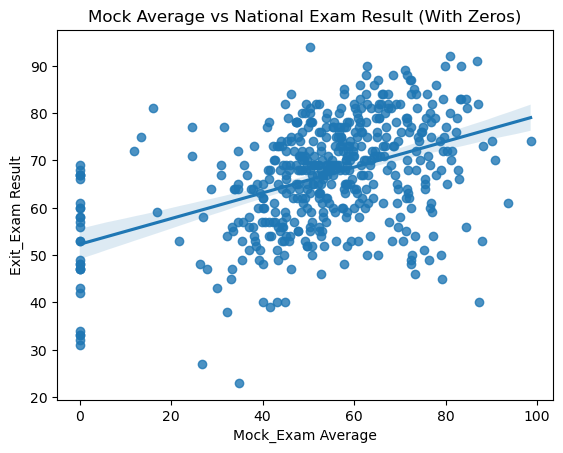

In [29]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Scatter plot with regression line (with zeros)
sns.regplot(x='Mock_Exam Average', y='Exit_Exam Result', data=df)
plt.title("Mock Average vs National Exam Result (With Zeros)")
plt.show()

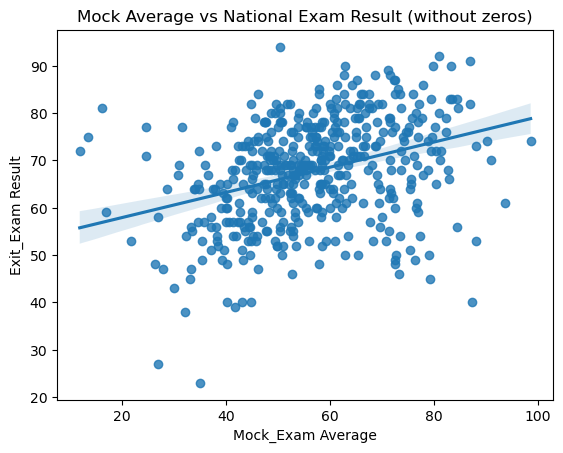

In [31]:
#Scatter plot without zeros
sns.regplot(x='Mock_Exam Average', y='Exit_Exam Result', data=df_nozero)
plt.title("Mock Average vs National Exam Result (without zeros)")
plt.show()

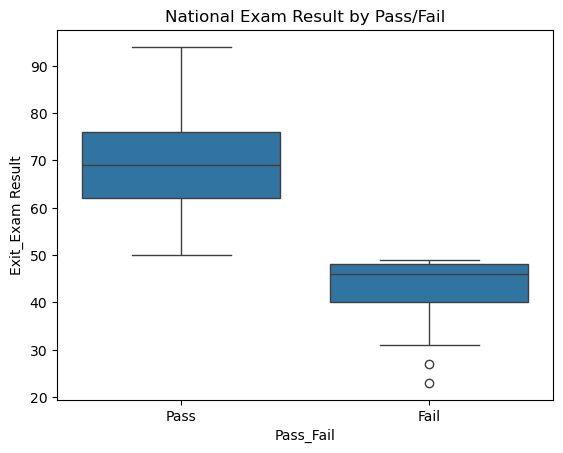

In [33]:
#Box plot of National Result by Pass/Fail
sns.boxplot(x='Pass_Fail', y='Exit_Exam Result', data=df)
plt.title("National Exam Result by Pass/Fail")
plt.show()

Conclusion
We conducted the analysis under two conditions: Including students with a mock_Exam average of 0 and excluding them, to answer our question and test the hypothesis.

With Zeros included:
- Mock_Exam scores explain about 20% of the variation in National exit exam results.
- The regression slope is positive and statistically significant (~0.27), supporting the hypothesis.
- However, the intercept indicates that students could still pass even with zero mock scores.

Without Zeros included:
- Mock exam scores explains about 12% of variation in National exit exam results.
- The regression slop remains positive and statistically significant (~0.27), still supporting the hypothesis.
-  This version provides a cleaner analysis, showing that among students who took the mock exam, higher scores predict higher national exam results.

Overall:
- Both analyses supoort the hypothesis that Mock exam scores significantly predict National exam results.
- since we have considered only one  predictor variable the explained variation is modest. Considering other factors such as study habits, attendance etc.) may play a substantial role in determining exam outcomes.
-  